In [46]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import genextreme
import nsEVDx as ns

#### Generating time series of non-stationary extremes


['B0 (location intercept)', 'B1 (location slope for covariate 1)', 'sigma (scale)', 'xi (shape)']


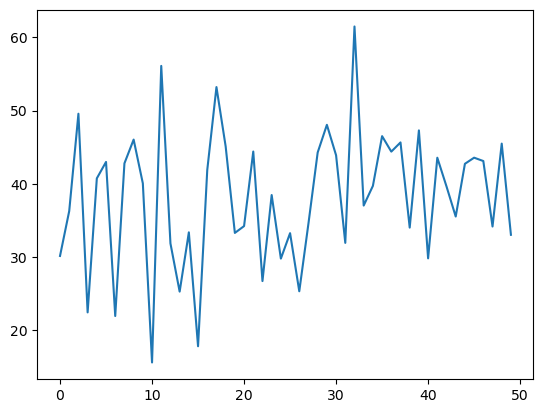

In [47]:
np.random.seed(112)
config = [1, 0, 0]
# location parameter is non-stationary and scale and shape parameters are stationary
# See Usage.md or https://nischalcs50.github.io/nsEVDx/ for more details on config
# checking the parameters corresponding to the config

print(ns.NonStationaryEVD.get_param_description(config=config, n_cov=1))
# checking the parameters corresponding to the config

params = [30, 0.2, 8, 0.15]  # setting the parameters for the non-stationary EVD model
cov = np.array(range(50))  # Generating a covariate that increases linearly with time
data = ns.NonStationaryEVD.ns_EVDrvs(genextreme, params, cov, config, size=50)

plt.plot(data)  # plotting the time serie of extremes tat increases linearly

#### Setting Piors

In [48]:
# Priors: normal for regression coefficients of location parameter,
#         half-normal for scale, normal for shape
prior_specs = [
    ("normal", {"loc": 30, "scale": 7}),
    ("normal", {"loc": 0, "scale": 0.3}),
    ("halfnormal", {"loc": 5, "scale": 5}),
    ("normal", {"loc": 0.1, "scale": 0.3}),
]
sampler = ns.NonStationaryEVD(
    config, data, cov, dist=genextreme, prior_specs=prior_specs
)
print(sampler.descriptions)

['B0 (location intercept)', 'B1 (location slope for covariate 1)', 'sigma (scale)', 'xi (shape)']


#### Running Bayesian algorithm to sample posterior distribution of parameters

In [68]:
np.random.seed(42)
# fitting a non-stationary GEV model to the data using
# Hamiltonian Monte Carlo (HMC) sampler
# Leave the line just below commented if you are not debugging
# logger.debug("Prior %s returned invalid logpdf...", ptype, param_idx, val, kwargs)
initial_params = [30, 0, 7, 0.12]
samples, a_rate, r_hat = sampler.MH_Mala(
    num_samples=2500, initial_params=initial_params,
    step_sizes=[1.15,0.08,0.75,0.05], T=5,
    burn_in=1000, num_chains=3, n_jobs=3
)


MCMC CONVERGENCE REPORT
-------------------------------------------------------
Average Acceptance: 57.47%
Convergence Check: PASSED (r_hat < 1.1)
-------------------------------------------------------

B0 (location intercept)        R-hat: 1.0083
B1 (location slope for covariate 1) R-hat: 1.0048
sigma (scale)                  R-hat: 1.0055
xi (shape)                     R-hat: 1.0073


#### Print results

In [69]:
print(f"acceptance_rate : {a_rate}")
print(f"r_hat : {r_hat}")
np.set_printoptions(suppress=True, precision=6)
sample_all_chains = np.vstack(samples)  # shape (num_chains*num_samples, num_params)
sample_mean = sample_all_chains.mean(axis=0)
print(f"Sample mean : {sample_mean}")

acceptance_rate : [0.594, 0.5552, 0.5748]
r_hat : [1.008288 1.004807 1.005451 1.007345]
Sample mean : [30.431314  0.167548  9.010915  0.202179]


#### Plot Convergence & Posterior Distributions

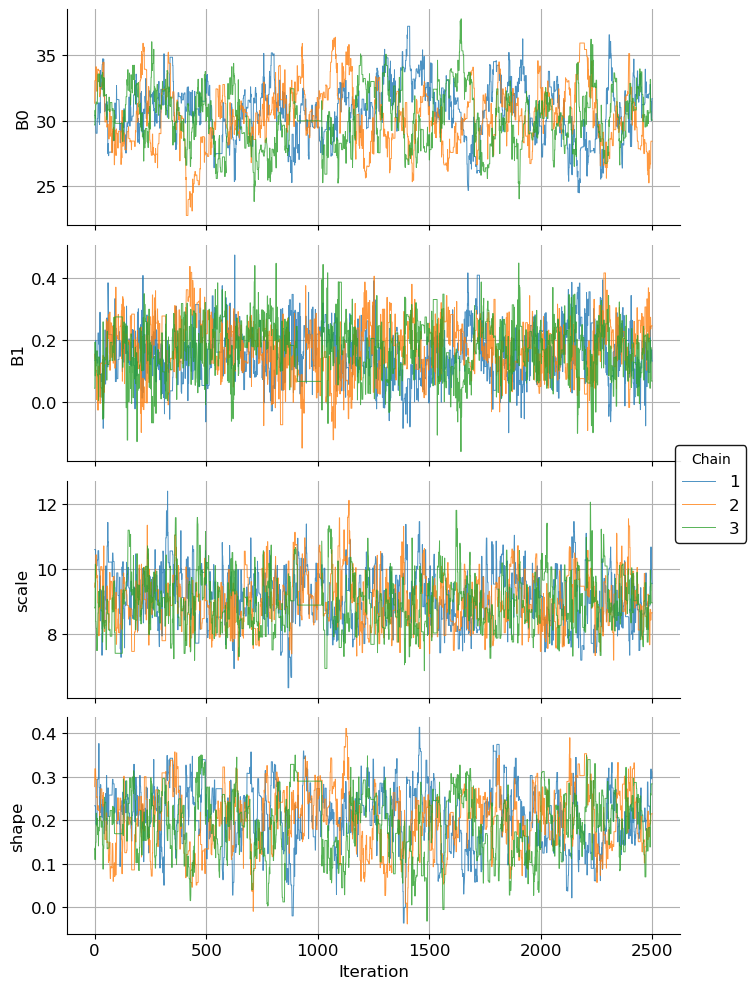

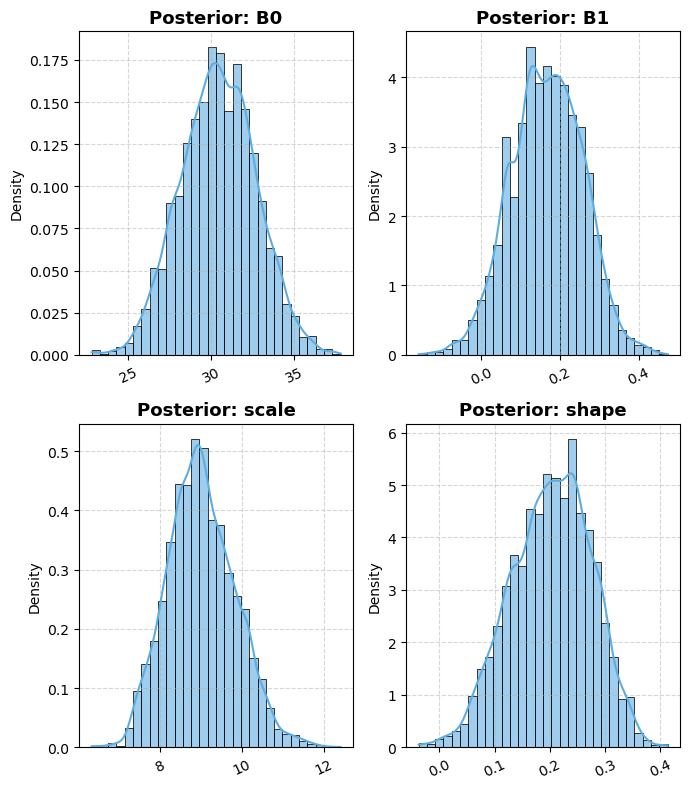

In [70]:
ns.plot_trace(samples, config, fig_size=(7, 10))
ns.plot_posterior(samples, config, fig_size=(7, 8))